In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import logomaker

from methylseqnet_repro.paths import annotations, configs

path_to_pwms_dir = annotations / "pwms" # files here need to be transposed before fed to logomaker

tfs_file = configs / 'transcription_factors.txt' #assumes methylseq-net and methylseq-sandbox are cloned in same dir
#tfs_file = None

tfs = []
if tfs_file is not None:
    with open(tfs_file, 'r') as file:
        tfs = file.read().splitlines()
    print(tfs)
else:
    print(f"Using all files in {path_to_pwms_dir}")

['ALX3', 'ARNT2', 'ARNTL', 'ATF2', 'ATF3', 'ATF4', 'ATF6', 'ATF7', 'BARHL2', 'BCL6', 'BCL6B', 'BHLHE40', 'BHLHE41', 'BSX', 'CDC5L', 'CDX1', 'CDX2', 'CDX4', 'CEBPA', 'CEBPB', 'CEBPD', 'CEBPE', 'CEBPG', 'CG1', 'CG10', 'CG2', 'CG3', 'CG5', 'CLOCK', 'CREB1', 'CREB3', 'CREB3L1', 'CREB5', 'CREM', 'CTCF', 'CUX1', 'DMRTC2', 'E2F2', 'E2F3', 'E2F4', 'E2F7', 'E2F8', 'EGR1', 'EGR2', 'EGR3', 'EGR4', 'ELF1', 'ELF2', 'ELF3', 'ELF4', 'ELF5', 'ELK1', 'ELK3', 'EN1', 'EN2', 'ERG', 'ESR1', 'ESRRB', 'ETS2', 'ETV1', 'ETV2', 'ETV3', 'ETV4', 'ETV5', 'FEV', 'FLI1', 'FOS', 'FOSB', 'FOSL1', 'FOSL2', 'FOXA1', 'FOXA2', 'FOXA3', 'FOXG1', 'FOXJ3', 'FOXP3', 'GABPA', 'GATA1', 'GATA2', 'GATA3', 'GATA4', 'GATA5', 'GBX2', 'GCM1', 'GCM2', 'GFI1', 'GLI2', 'GLIS1', 'GLIS2', 'GMEB1', 'GMEB2', 'GRHL1', 'GSX2', 'HES1', 'HES2', 'HES5', 'HES7', 'HEY1', 'HEY2', 'HLF', 'HNF1A', 'HNF1B', 'HNF4A', 'HOXA1', 'HOXA11', 'HOXA13', 'HOXA2', 'HOXA4', 'HOXA5', 'HOXA6', 'HOXA7', 'HOXB1', 'HOXB13', 'HOXB2', 'HOXB5', 'HOXB6', 'HOXB7', 'HOXB8',

In [2]:
def load_pwm_csv(filepath):
    """ Loads a wide-format CSV, transposes it to tall-format, 
    and returns only the canonical A, C, G, T values. """
    # load with the first column (bases) as index, transpose
    df = pd.read_csv(filepath, index_col=0).T
    
    # headers to uppercase
    df.columns = df.columns.astype(str).str.upper()
    
    # keep A, C, G, T columns
    # .get() or reindex ensures no crash if a column is missing
    bases = ['A', 'C', 'G', 'T']
    pwm_df = df.reindex(columns=bases).fillna(0)
    
    # remove original row names, don't need across motif positions
    pwm_df.reset_index(drop=True, inplace=True)
    
    # data is numeric for plotting
    return pwm_df.apply(pd.to_numeric)

def plot_logo(pwm_df, title=None, figsize=(10, 3), ax=None):
    """ Plot a sequence logo from a PWM DataFrame, converting to Bits. """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # transform probs to bits, calculates height based on: 2 - Entropy
    info_df = logomaker.transform_matrix(pwm_df, from_type='probability', to_type='information')
    
    logo = logomaker.Logo(info_df, ax=ax)
    
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    logo.style_xticks(rotation=0, fmt='%d', anchor=0)
    ax.set_xlabel('Position', fontsize=12)
    ax.set_ylabel('Bits', fontsize=12)
    ax.set_ylim([0, 2.1]) # Bits for DNA max out at 2.0
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    
    return ax

In [3]:
# collect list of CSVs

pwm_dir = Path(path_to_pwms_dir)
pwm_files = list(pwm_dir.glob('*.csv'))
#print(pwm_files)

print(f"Found {len(pwm_files)} CSV file(s) in {pwm_dir}")
for f in pwm_files[:10]:
    print(f"  - {f}")
if len(pwm_files) > 10:
    print(f"  ... and {len(pwm_files) - 10} more")

Found 760 CSV file(s) in /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/ESRRG.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/ARID3A.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/DRGX.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/ZNF281.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/ETV1.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/MAFB.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/MEOX2.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/HOXB2.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/TFAP2E.csv
  - /global/scratch/users/arbajwa/scbasset_data/Homo_sapiens_motif_fasta/pwms/MLXIP.csv
  ... and 750 more


In [4]:
# load PWMs into memory

loaded_pwms = {}
failed_files = []

if tfs_file is not None:
    new_pwm_files = []
    for pwm_file in pwm_files:
        if pwm_file.name.split(".csv")[0] in tfs:
            new_pwm_files.append(pwm_file)
    pwm_files = new_pwm_files  
#print(pwm_files)

for pwm_file in sorted(pwm_files):
    try:
        pwm_df = load_pwm_csv(pwm_file)
        loaded_pwms[pwm_file.stem] = pwm_df
        print(f"✓ Loaded: {pwm_file.name}")
    except Exception as e:
        failed_files.append((pwm_file.name, str(e)))
        print(f"✗ Failed to load {pwm_file.name}: {e}")

print(f"\nSuccessfully loaded {len(loaded_pwms)} PWM(s)")
if failed_files:
    print(f"Failed to load {len(failed_files)} file(s)")

✓ Loaded: ALX3.csv
✓ Loaded: ARNT2.csv
✓ Loaded: ARNTL.csv
✓ Loaded: ATF2.csv
✓ Loaded: ATF3.csv
✓ Loaded: ATF4.csv
✓ Loaded: ATF6.csv
✓ Loaded: ATF7.csv
✓ Loaded: BARHL2.csv
✓ Loaded: BCL6.csv
✓ Loaded: BCL6B.csv
✓ Loaded: BHLHE40.csv
✓ Loaded: BHLHE41.csv
✓ Loaded: BSX.csv
✓ Loaded: CDC5L.csv
✓ Loaded: CDX1.csv
✓ Loaded: CDX2.csv
✓ Loaded: CDX4.csv
✓ Loaded: CEBPA.csv
✓ Loaded: CEBPB.csv
✓ Loaded: CEBPD.csv
✓ Loaded: CEBPE.csv
✓ Loaded: CEBPG.csv
✓ Loaded: CG1.csv
✓ Loaded: CG10.csv
✓ Loaded: CG2.csv
✓ Loaded: CG3.csv
✓ Loaded: CG5.csv
✓ Loaded: CLOCK.csv
✓ Loaded: CREB1.csv
✓ Loaded: CREB3.csv
✓ Loaded: CREB3L1.csv
✓ Loaded: CREB5.csv
✓ Loaded: CREM.csv
✓ Loaded: CTCF.csv
✓ Loaded: CUX1.csv
✓ Loaded: DMRTC2.csv
✓ Loaded: E2F2.csv
✓ Loaded: E2F3.csv
✓ Loaded: E2F4.csv
✓ Loaded: E2F7.csv
✓ Loaded: E2F8.csv
✓ Loaded: EGR1.csv
✓ Loaded: EGR2.csv
✓ Loaded: EGR3.csv
✓ Loaded: EGR4.csv
✓ Loaded: ELF1.csv
✓ Loaded: ELF2.csv
✓ Loaded: ELF3.csv
✓ Loaded: ELF4.csv
✓ Loaded: ELF5.csv
✓ Loaded: 

In [ ]:
def plot_single_pwm(loaded, name, **kwargs):
    # print(loaded[name])
    plot_logo(loaded[name], title=name, **kwargs)

           A         C         G         T
0   0.095290  0.318729  0.083242  0.502738
1   0.182913  0.158817  0.453450  0.204819
2   0.307777  0.053669  0.491785  0.146769
3   0.061336  0.876232  0.023001  0.039430
4   0.008762  0.989047  0.000000  0.002191
5   0.814896  0.014239  0.071194  0.099671
6   0.043812  0.578313  0.365827  0.012048
7   0.117325  0.474781  0.052632  0.355263
8   0.933114  0.012061  0.035088  0.019737
9   0.005488  0.000000  0.991218  0.003293
10  0.365532  0.003293  0.621295  0.009879
11  0.059276  0.013172  0.553238  0.374314
12  0.013187  0.000000  0.978022  0.008791
13  0.061538  0.008791  0.851648  0.078022
14  0.114411  0.806381  0.005501  0.073707
15  0.409241  0.014301  0.557756  0.018702
16  0.090308  0.530837  0.338106  0.040749
17  0.128855  0.354626  0.080396  0.436123
18  0.442731  0.199339  0.292952  0.064978
           A         C         G         T
0   0.411477  0.021737  0.513117  0.053668
1   0.011701  0.057065  0.042424  0.888809
2   0.07793

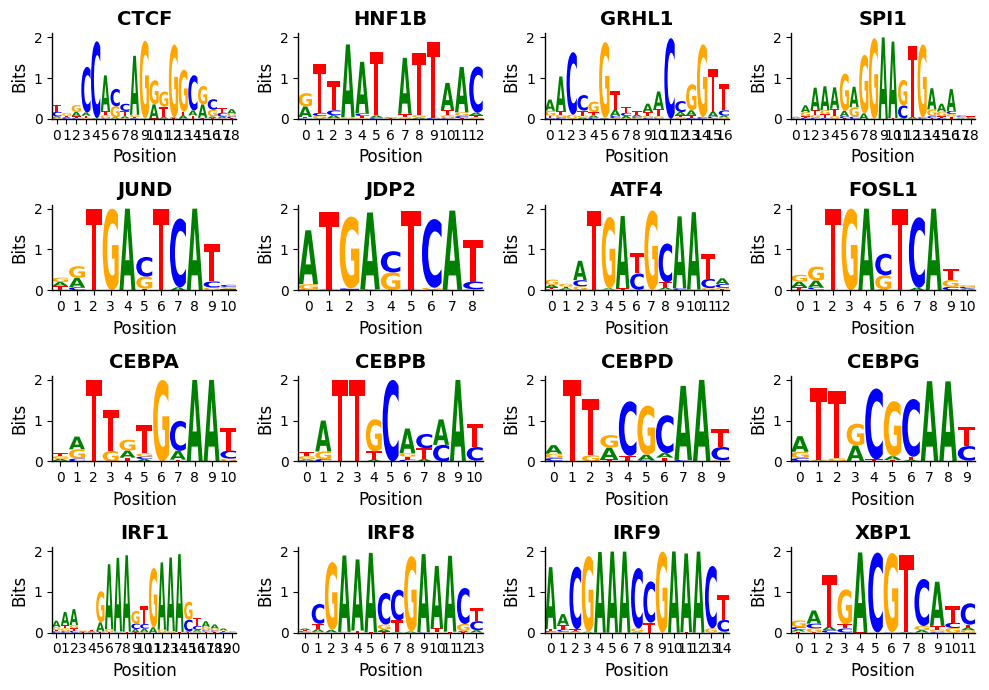

In [26]:
tfs_to_plot = ['CTCF','HNF1B','GRHL1','SPI1','JUND','JDP2','ATF4','FOSL1','CEBPA','CEBPB','CEBPD','CEBPG','IRF1','IRF8','IRF9','XBP1',]
subplots_array_size = int(np.ceil(np.sqrt(len(tfs_to_plot))))
fig, axs = plt.subplots(subplots_array_size, subplots_array_size, figsize=(10, 7))

for tf_idx, tf_to_plot in enumerate(tfs_to_plot):
    plot_single_pwm(loaded_pwms, tf_to_plot, ax=axs[tf_idx // subplots_array_size, tf_idx % subplots_array_size])

fig.tight_layout()

           A         C         G         T
0   0.235162  0.079507  0.494961  0.190370
1   0.186123  0.128855  0.450441  0.234581
2   0.658084  0.208033  0.130793  0.003090
3   0.000000  0.000000  0.007085  0.992915
4   0.016964  0.000000  0.973214  0.009821
5   0.972618  0.000000  0.000000  0.027382
6   0.002345  0.436108  0.010551  0.550996
7   0.000902  0.000000  0.995491  0.003607
8   0.039722  0.832175  0.015889  0.112214
9   0.973941  0.022801  0.000000  0.003257
10  0.991071  0.003348  0.001116  0.004464
11  0.000000  0.255278  0.059501  0.685221
12  0.478613  0.314451  0.116763  0.090173


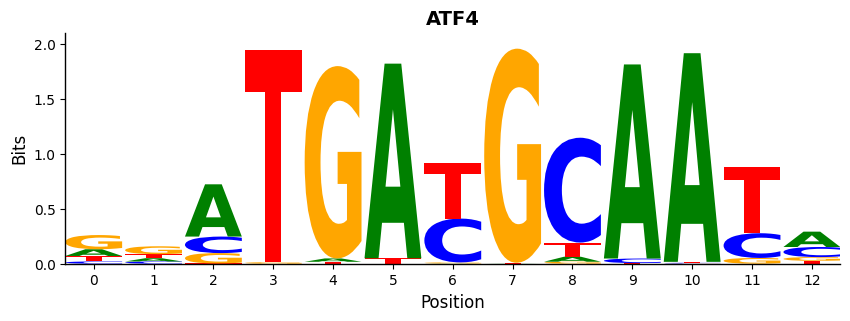

In [7]:
plot_single_pwm(loaded_pwms, 'ATF4')

      A     C     G     T
0  0.25  0.25  0.25  0.25
1  0.25  0.25  0.25  0.25
2  0.25  0.25  0.25  0.25
3  0.25  0.25  0.25  0.25
4  0.25  0.25  0.25  0.25


/clusterfs/nilah/ayesha/envs/methylseq/lib/python3.12/site-packages/logomaker/src/Logo.py:1062: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.set_ylim([ymin, ymax])


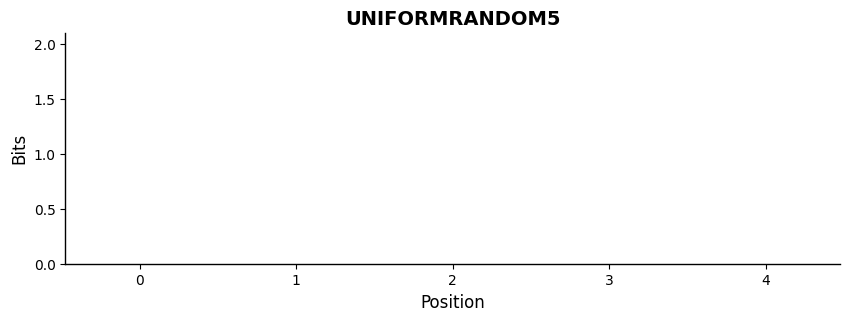

In [8]:
# sanity check
plot_single_pwm(loaded_pwms, 'UNIFORMRANDOM5') # won't show anything because unif prob is converted to zero info

In [ ]:
# sanity check
plot_single_pwm(loaded_pwms, 'CG2') # deterministic, CGs of specified length

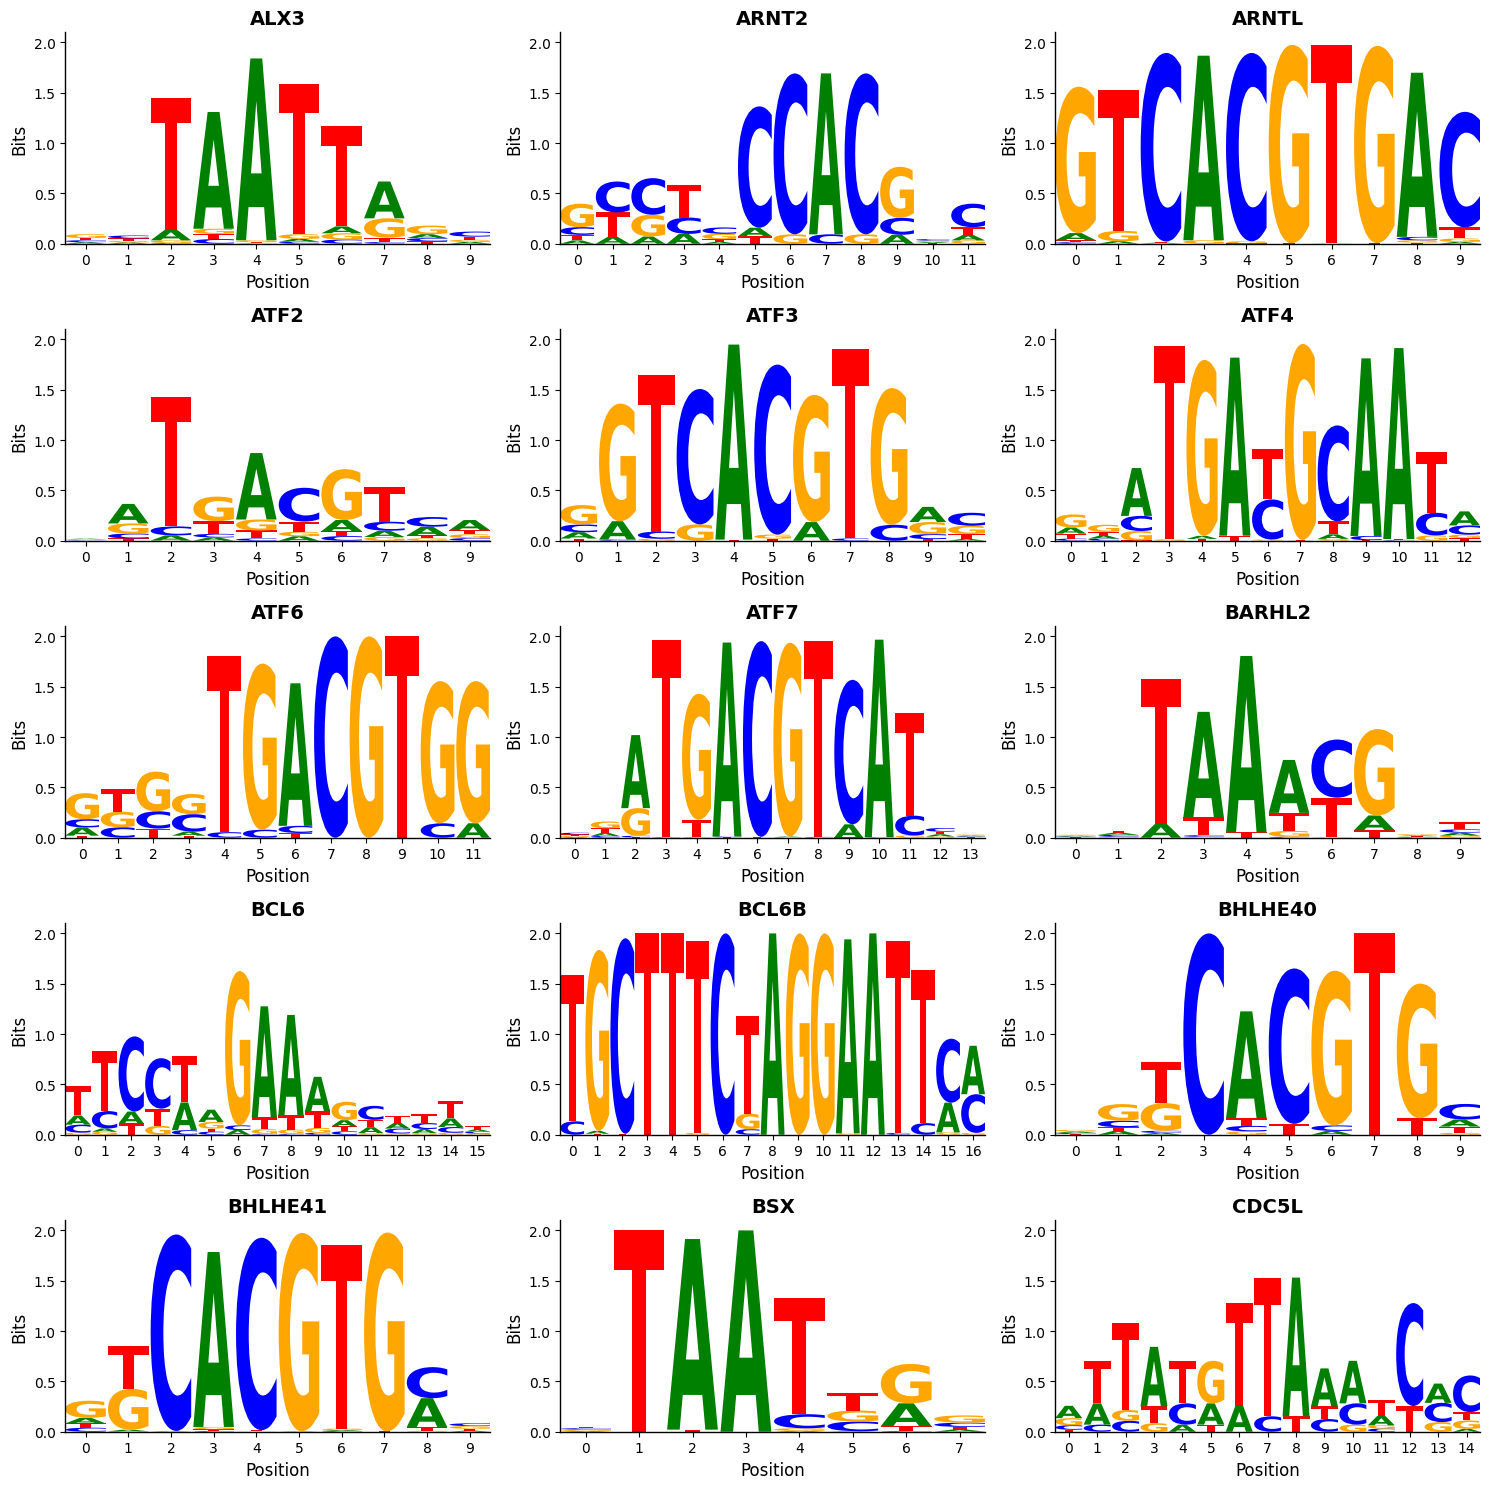

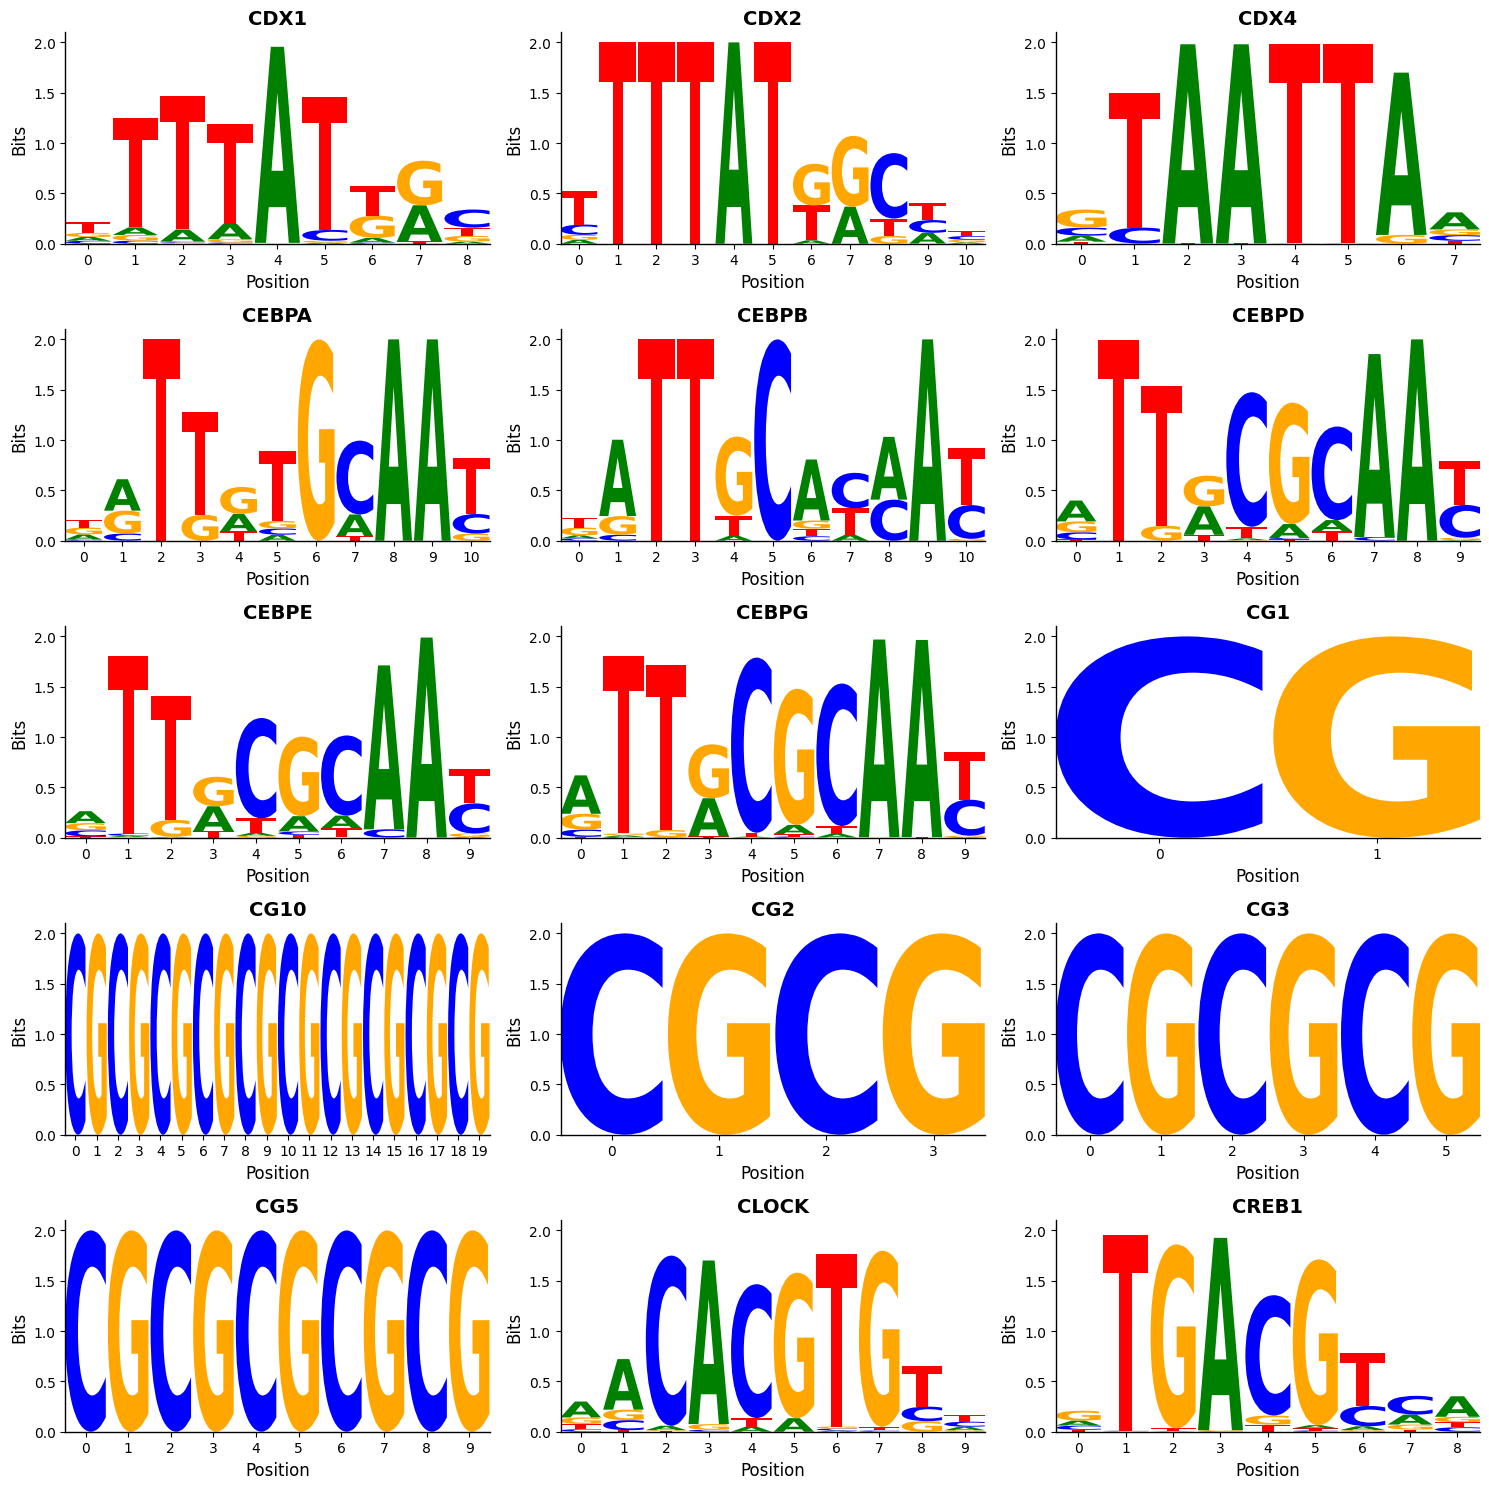

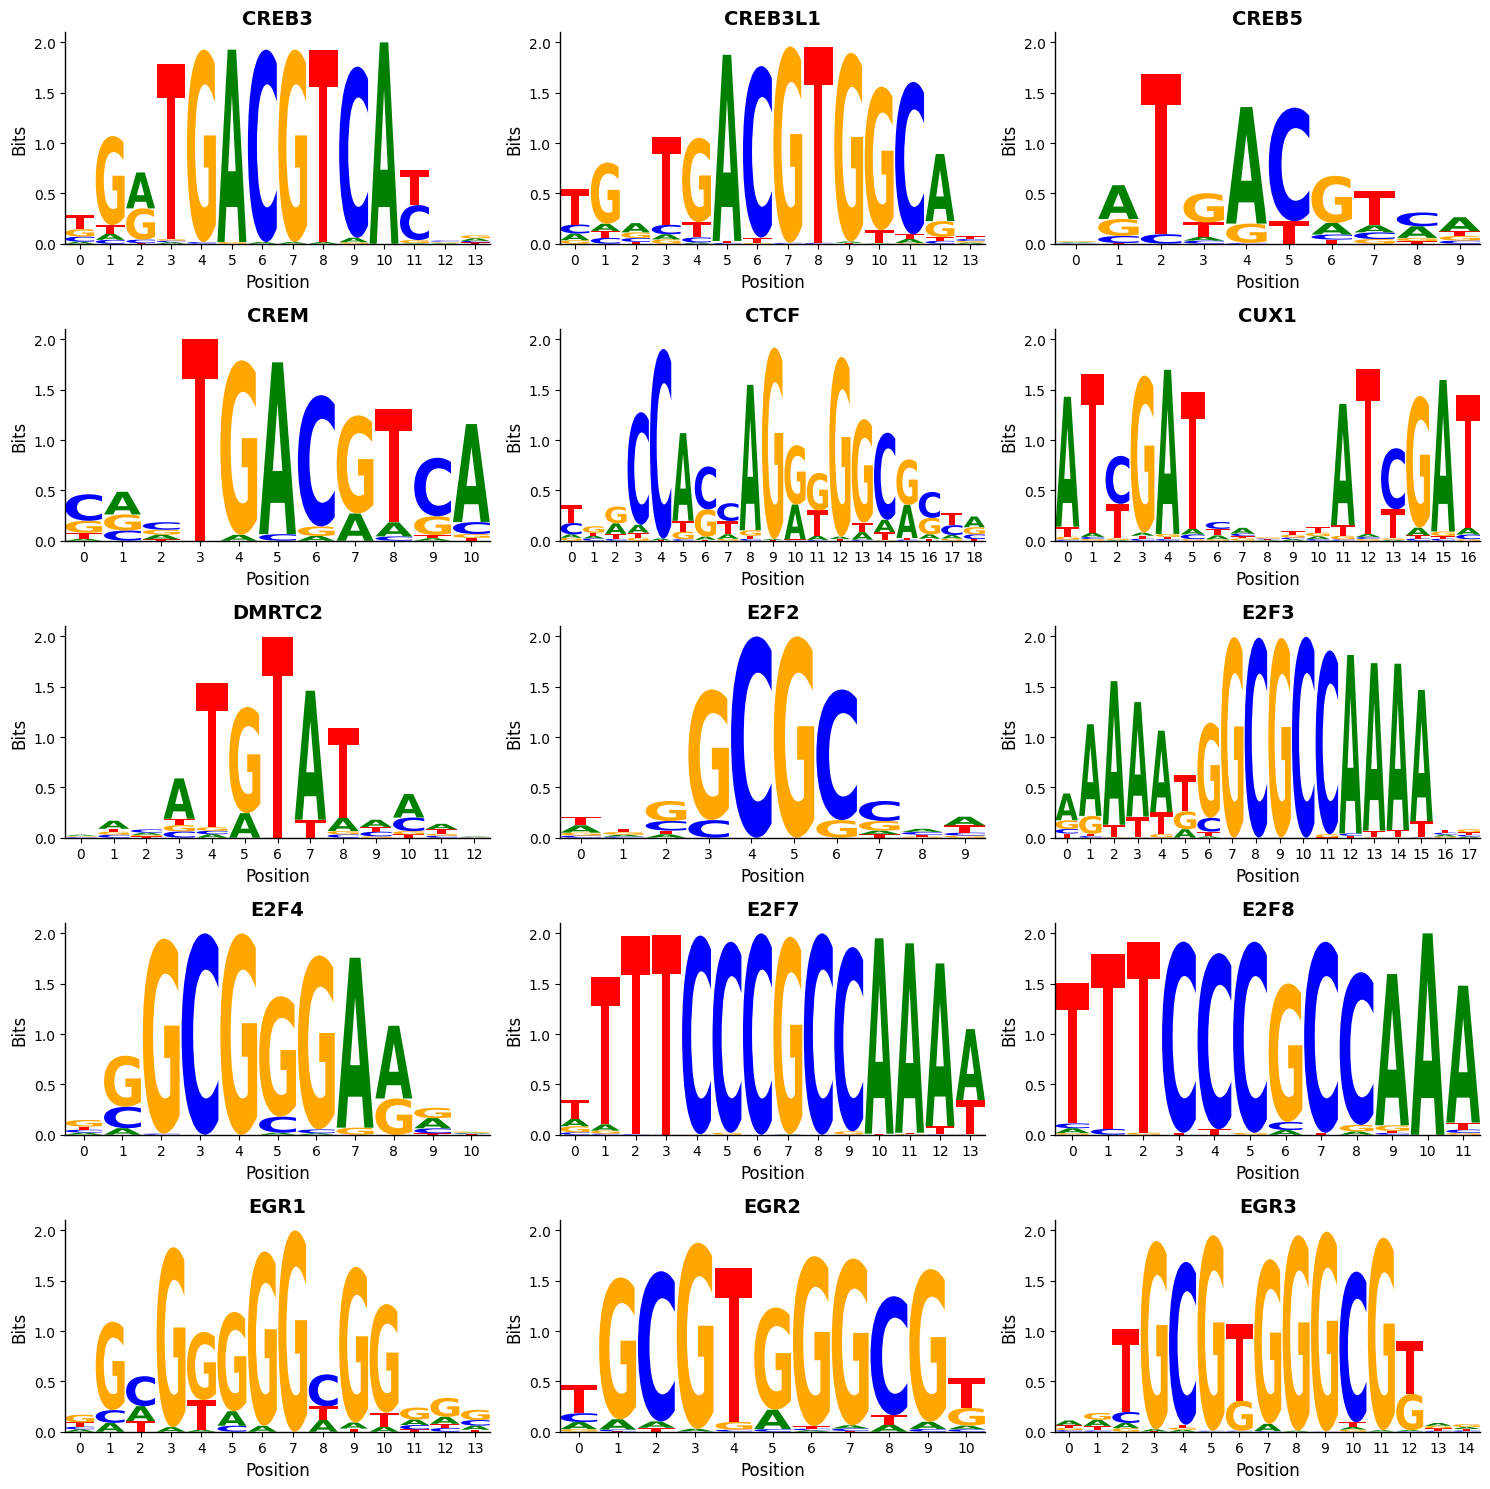

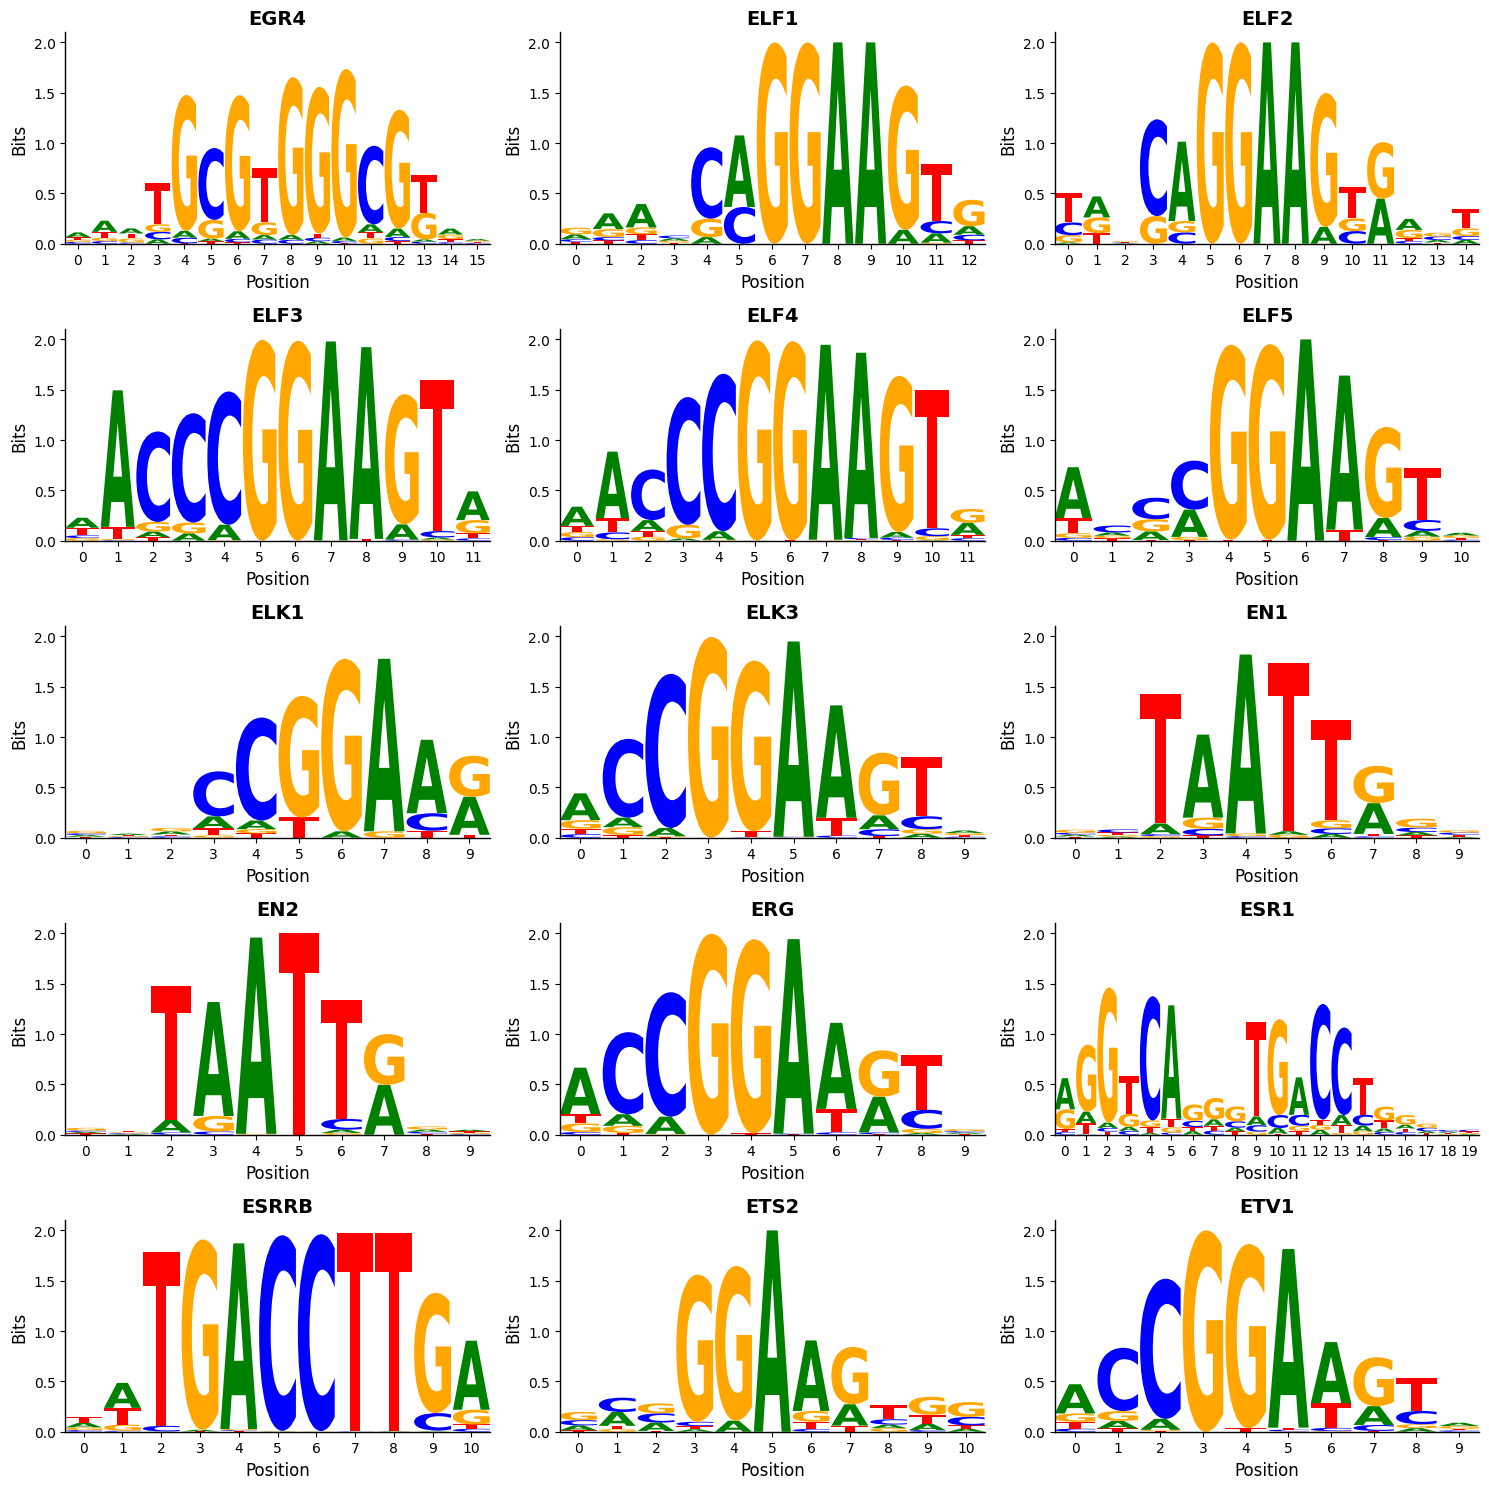

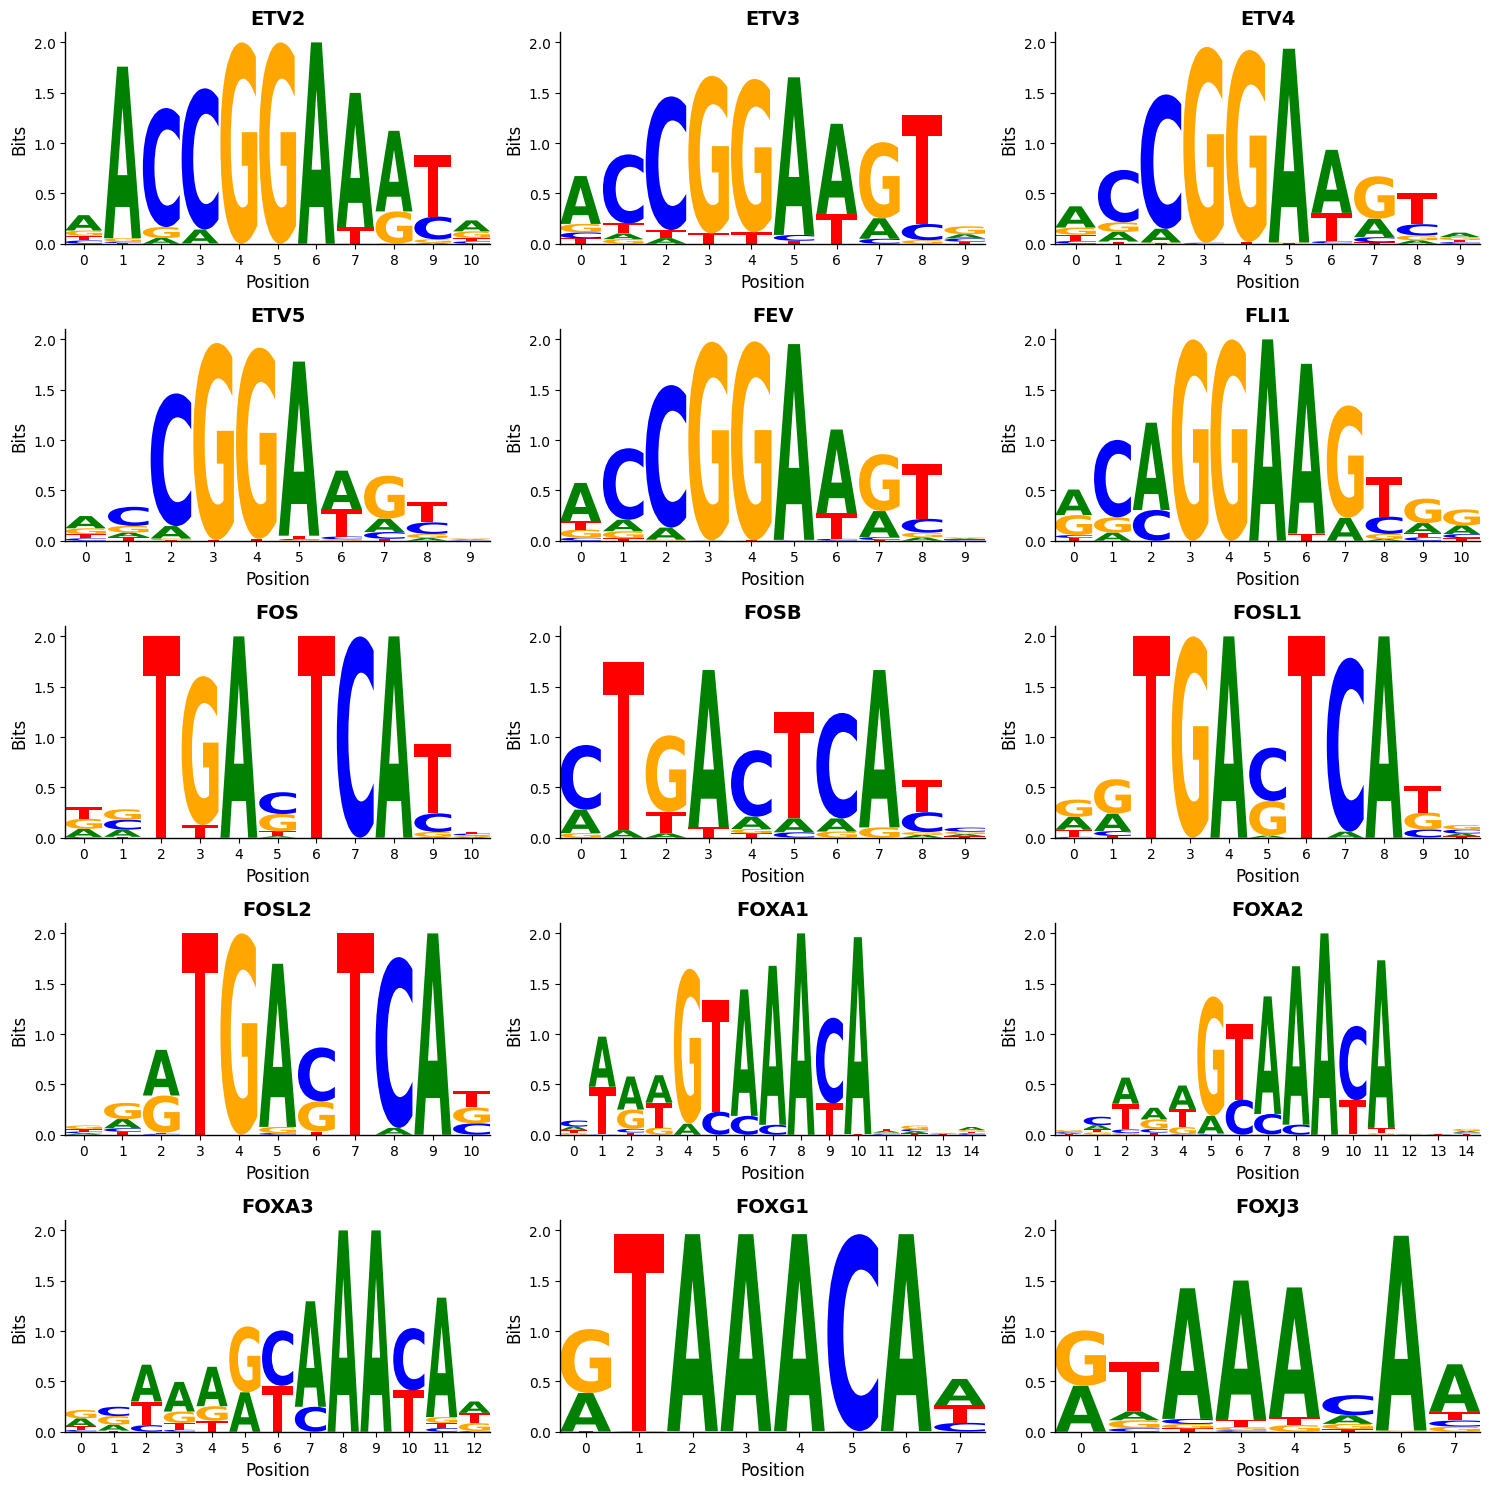

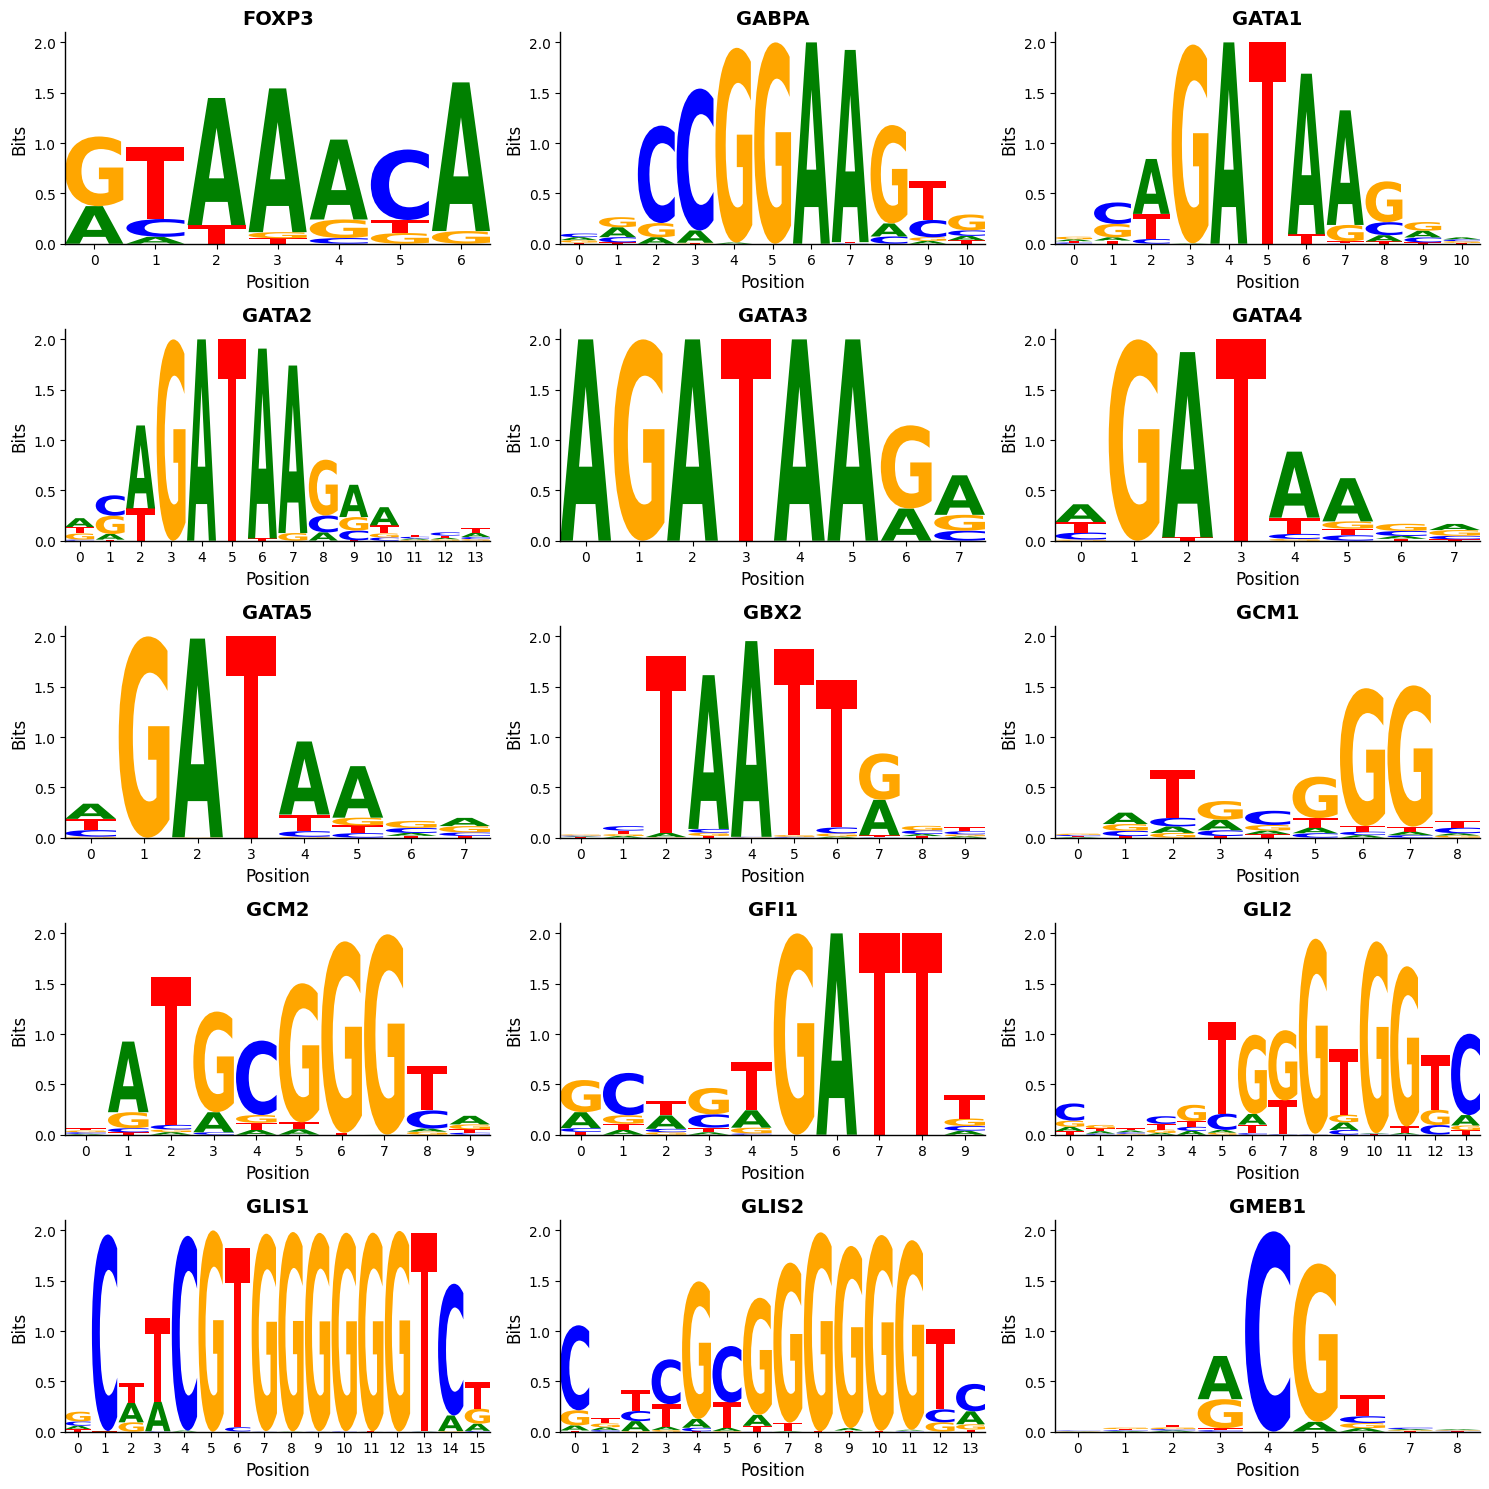

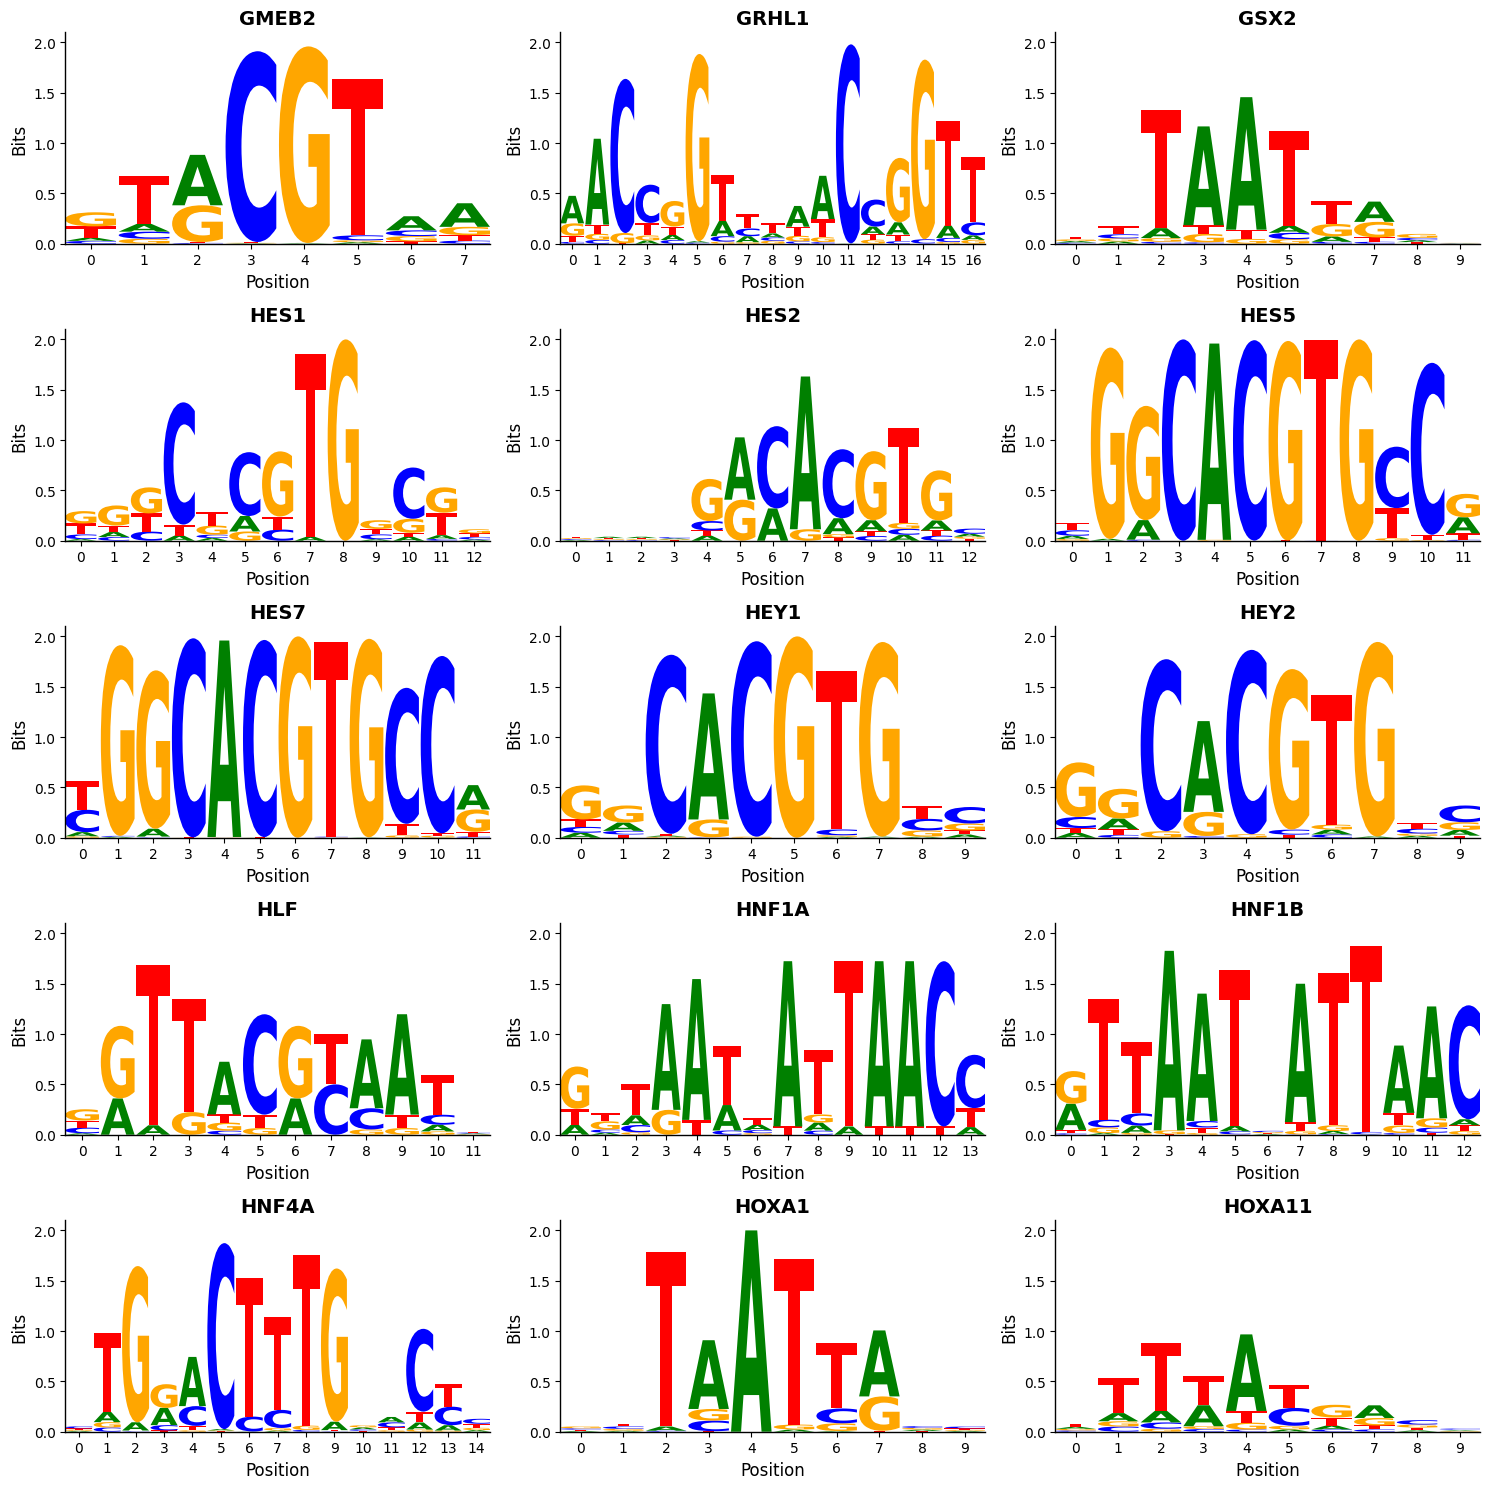

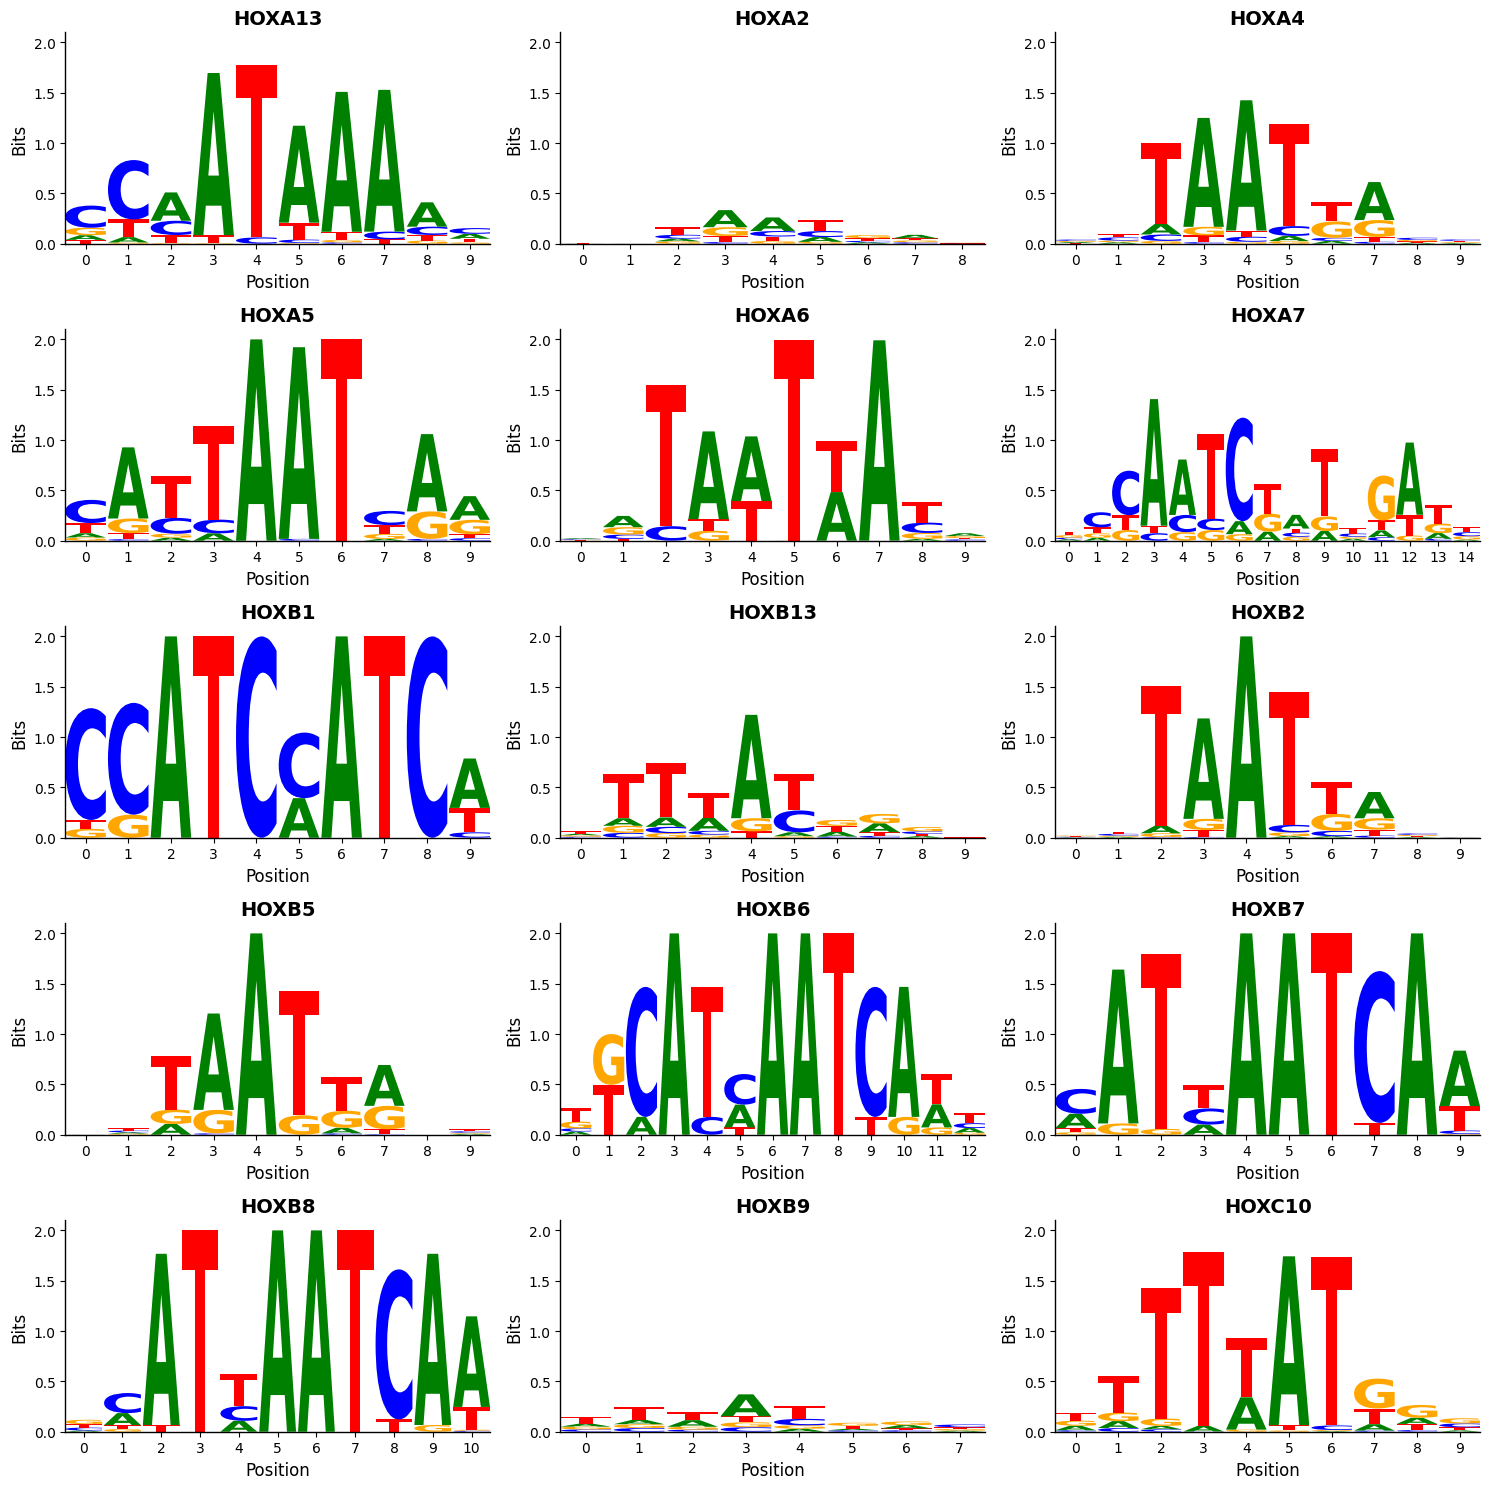

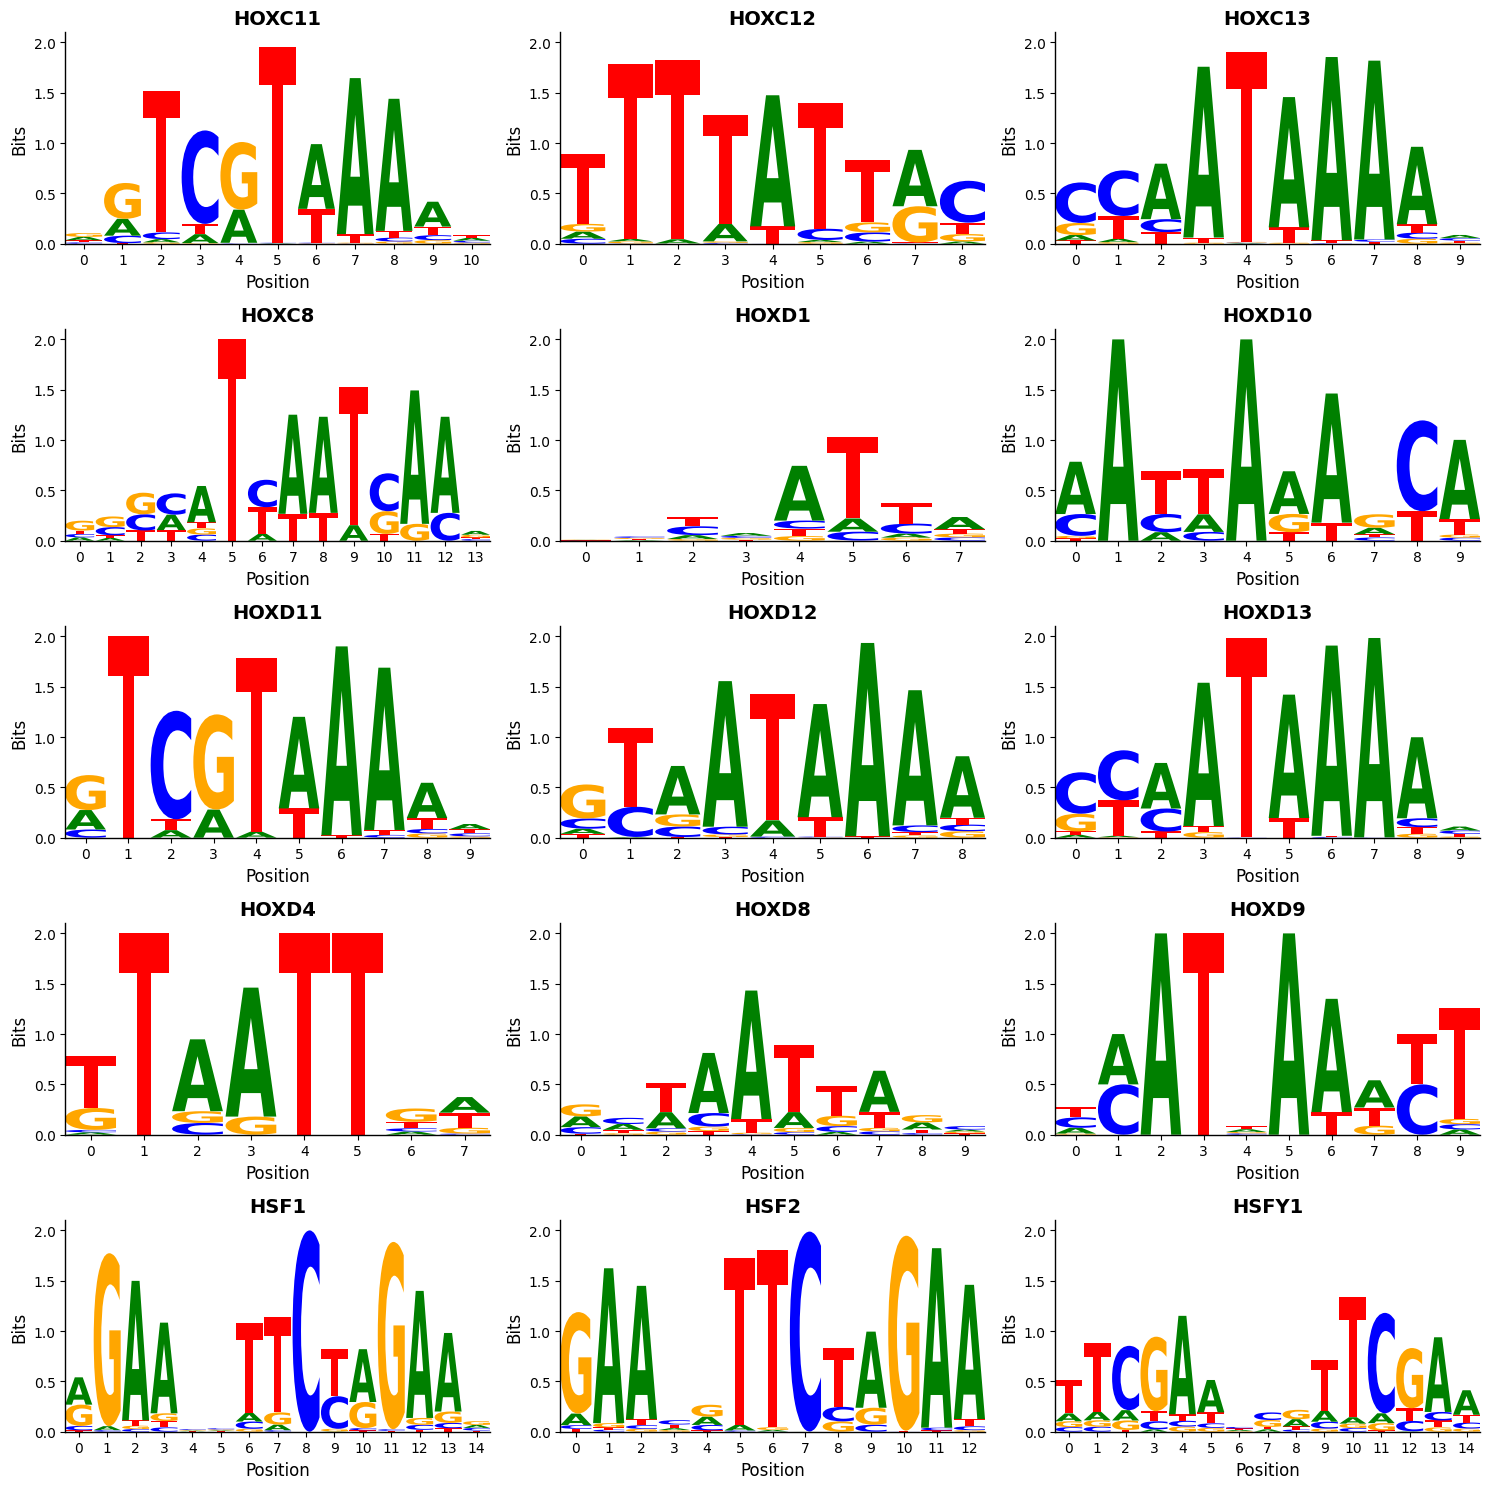

In [ ]:
# plotting configuration - partition for subplots and sorted order
pwms_per_page = 15
cols = 3
height_per_row = 3 
items = list(sorted(loaded_pwms.items()))

# loop through PWMs in chunks
for i in range(0, len(items), pwms_per_page):
    chunk = items[i : i + pwms_per_page]
    n_in_chunk = len(chunk)
    
    rows = (n_in_chunk + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, height_per_row * rows), squeeze=False)
    
    # Simple and robust: squeeze=False makes it 2D, flatten makes it 1D
    flat_axes = axes.flatten()
        
    for idx, (name, pwm_df) in enumerate(chunk):
        plot_logo(pwm_df, title=name, ax=flat_axes[idx])
        
    # Hide unused subplots (the empty ones in the grid)
    for j in range(idx + 1, len(flat_axes)):
        flat_axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()